# 9. Ray-traced voxels

`sylva.voxels` traces every pulse through a voxel grid and estimates the
attenuation coefficient λ of each voxel from how far pulses got, then plant area
density as λ / G. It follows AMAPVox and the rayvoxel tool; see the
[guide](../guide/voxels.md) for the estimators.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import Shots, voxels

## Tracing a real tile

The Litchfield pulses, with the echoes' `classification` so the terrain can be
left out of the plant area. `occlusion=True` also records what the pulses never
reached.

In [2]:
shots = Shots.load(DATA / "litch_tile_shots.parquet")
grid = voxels.ray_voxelize(
    shots, voxel_size=0.5, bounds=((0, 0, 0), (20, 20, 18)),
    ground_class=2, leaf_classes=[4], attenuation=["fpl", "ppl"], occlusion=True,
)
print(grid)
print("raw fields:", ", ".join(grid.fields[:10]), "...")

RayVoxelGrid(40x40x36 @ 0.5 m)
raw fields: num_hits, num_beams, num_beams_occluded, num_unbound_rays, num_miss_rays, num_hit_leaf, num_hit_wood, num_hit_plant, num_beams_weighted, path_length ...


`state` is 0 unobserved, 1 occluded (only reached behind a last echo),
2 empty, 3 filled. Arrays are `(nz, ny, nx)`. Here 97 % of the tile was
observed and 3 % is occluded, which is what many scan positions buy you.

{'unobserved': '0.0%', 'occluded': '2.9%', 'empty': '80.1%', 'filled': '17.0%'}
{'observed': 0.971, 'occluded': 0.029, 'unobserved': 0.0, 'top': 17.75}


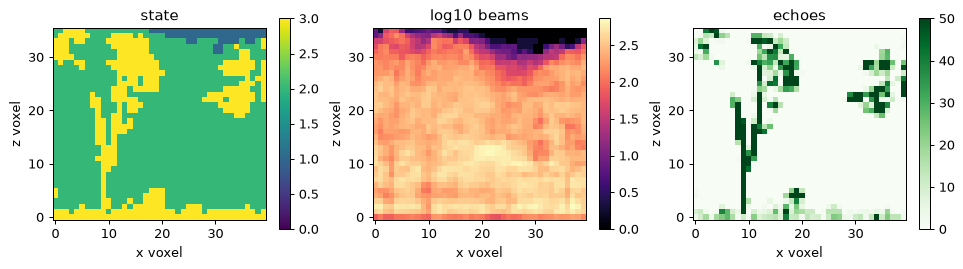

In [3]:
state = grid.state
names = ["unobserved", "occluded", "empty", "filled"]
print({n: f"{np.mean(state == i):.1%}" for i, n in enumerate(names)})
print({k: round(v, 3) for k, v in grid.occlusion_profile()["total"].items()})
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
j = 15                                        # the row of voxels at y = 7.5 m
for a, (v, title, kw) in zip(ax, [
        (state[:, j, :], "state", dict(cmap="viridis", vmin=0, vmax=3)),
        (np.log10(grid.num_beams[:, j, :] + 1), "log10 beams", dict(cmap="magma")),
        (grid.num_hits[:, j, :], "echoes", dict(cmap="Greens", vmax=50))]):
    im = a.imshow(v, origin="lower", **kw); a.set(title=title, xlabel="x voxel", ylabel="z voxel")
    fig.colorbar(im, ax=a, shrink=0.8)

## Attenuation, and where the tile can support an estimate

FPL and PPL agree where voxels are well sampled and diverge where they are not,
which is the useful diagnostic. Before reading any profile, look at how many
beams reached each layer: the tile holds one real scan position (its corner)
plus rays from the rest of the plot clipped at the boundary, so sampling falls
away with height. Layers whose voxels see only a few tens of beams produce
large, meaningless λ -- a voxel with 20 beams, 2 echoes and short path lengths
reads as dense -- and `profile` averages over whichever voxels pass
`min_beams`, so a stricter threshold can *raise* the number rather than
settle it.

median beams per voxel stays above 200 up to 11.2 m, and falls below 20 above 16.2 m


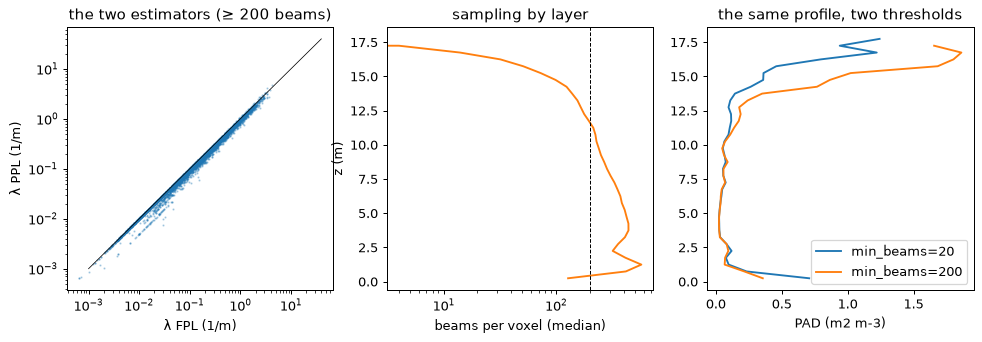

In [4]:
beams = np.median(grid.num_beams, axis=(1, 2))
z = grid.z_levels() + 0.25
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].loglog(grid.attenuation_fpl[(grid.num_beams >= 200) & (grid.num_hits > 0)],
             grid.attenuation_ppl[(grid.num_beams >= 200) & (grid.num_hits > 0)], ".", ms=1.5, alpha=0.3)
ax[0].plot([1e-3, 40], [1e-3, 40], "k", lw=0.6)
ax[0].set(xlabel="λ FPL (1/m)", ylabel="λ PPL (1/m)", title="the two estimators (≥ 200 beams)")
ax[1].plot(beams, z, "C1")
ax[1].axvline(200, color="k", ls="--", lw=0.8)
ax[1].set(xscale="log", xlabel="beams per voxel (median)", ylabel="z (m)", title="sampling by layer")
for mb in (20, 200):
    ax[2].plot(grid.profile("pad_ppl", min_beams=mb), z, label=f"min_beams={mb}")
ax[2].set(xlabel="PAD (m2 m-3)", title="the same profile, two thresholds"); ax[2].legend()
usable = z[beams >= 200].max()
print(f"median beams per voxel stays above 200 up to {usable:.1f} m, and falls below 20 above "
      f"{z[beams >= 20].max():.1f} m")

Read the profile up to that height and no further. Summed over the
well-sampled layers it comes to about 0.7 -- the grass layer and the lower
canopy, and in the same range as the plot's hinge PAI of 0.87. Summed over
every layer it comes to 6.3, which is the sparsely sampled top of the tile
inventing plant area. A 20 x 20 m cut-out cannot give a plot's plant area
index either way: its rays were clipped at the boundary and the upper canopy is
barely sampled. The [canopy benchmark](../benchmarks/canopy.md) has the plot
values from whole scans, where Sylva's profiles match pylidar-tls-canopy to
within 4 %.

PAI over the well-sampled layers only: 0.74  over every layer: 6.31


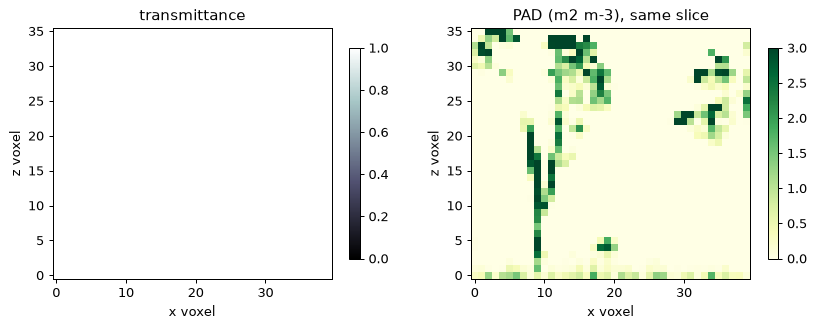

In [5]:
ok = beams >= 200
print("PAI over the well-sampled layers only:",
      round(float(np.nansum(grid.profile("pad_ppl", min_beams=200)[ok]) * grid.voxel_size), 2),
      " over every layer:",
      round(float(np.nansum(grid.profile("pad_ppl", min_beams=200)) * grid.voxel_size), 2))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, (v, title) in zip(ax, [(grid.transmittance[:, j, :], "transmittance"),
                              (grid.pad_ppl[:, j, :], "PAD (m2 m-3), same slice")]):
    im = a.imshow(v, origin="lower", cmap="bone" if "trans" in title else "YlGn",
                  vmin=0, vmax=1 if "trans" in title else 3)
    a.set(title=title, xlabel="x voxel", ylabel="z voxel"); fig.colorbar(im, ax=a, shrink=0.8)

## Checking the estimators against a known scene

To see whether the numbers are right, the scene has to be known. Four
synthetic scans of a scene with a known leaf area: the estimate should be the
right size, and low, because the pseudo-scanner sees each leaf disc through
only a few points.

In [6]:
scene = synthetic.forest()
positions = [(3, 3), (17, 3), (3, 17), (17, 17), (10, 10)]
sim = Shots.concatenate([
    synthetic.scan(scene, origin=(x, y, synthetic.terrain_height(x, y) + 1.5), resolution_deg=0.2)
    for x, y in positions])
sim_grid = voxels.ray_voxelize(sim, 0.5, ((0, 0, -0.5), (20, 20, 16.5)), ground_class=2,
                               leaf_classes=[4], wood_classes=[5], attenuation=["fpl", "ppl"])
pai = float(np.nansum(sim_grid.profile("pad_ppl", min_beams=20)) * 0.5)
lai = float(np.nansum(sim_grid.profile("lad_ppl", min_beams=20)) * 0.5)
print(f"PAI {pai:.2f}  LAI {lai:.2f}  true LAI of the scene {synthetic.leaf_area(scene) / 20**2:.2f}")

PAI 0.23  LAI 0.17  true LAI of the scene 0.30


## Leaf angles

With `inclination=True`, normals of the echoes give an inclination angle
distribution per tree, and G is integrated over it and over the tree's beam
zeniths instead of assuming a spherical distribution. The synthetic leaves are
randomly oriented discs, so the result should be close to spherical with
G ≈ 0.5.

tree 1: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.47
tree 2: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.50
tree 3: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.47
tree 4: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.48


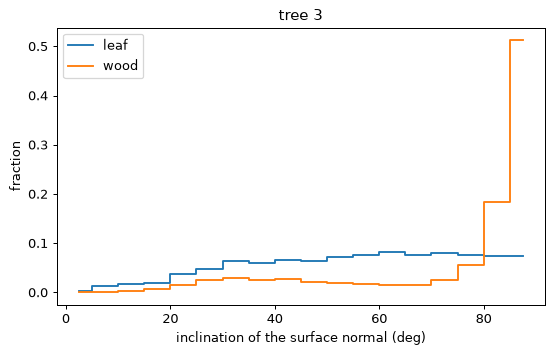

In [7]:
inc = voxels.ray_voxelize(sim, 0.5, ((0, 0, -0.5), (20, 20, 16.5)), ground_class=2,
                          leaf_classes=[4], wood_classes=[5], inclination=True)
for tid, t in inc.tree_iad.items():
    print(f"tree {tid}: leaves {t['liad_de_wit']:12s} G_leaf {t['g_leaf']:.2f}   "
          f"wood {t['wiad_de_wit']:12s} G_wood {t['g_wood']:.2f}")
t = inc.tree_iad[3]
plt.step(np.degrees(t["bin_centres"]), t["liad"], where="mid", label="leaf")
plt.step(np.degrees(t["bin_centres"]), t["wiad"], where="mid", label="wood")
plt.gca().set(xlabel="inclination of the surface normal (deg)", ylabel="fraction", title="tree 3"); plt.legend();

## Wood volume, files and streaming

QSM cylinders can be rasterised into the same grid; `write` produces an AMAPVox `.vox` file or a text table; and a shots file is voxelised without being loaded.

In [8]:
from sylva import qsm
tree3 = scene[scene.attrs["tree_id"] == 3]
model = qsm.build_qsm(tree3[tree3.attrs["classification"] == 5], base_xy=(8.0, 15.0))
sim_grid.add_wood_volume(model)
print(f"wood volume in the grid {sim_grid.wood_volume.sum():.3f} m3 of {model.total_volume:.3f} m3 in the QSM")

n = grid.write("tile.vox")
print(n, "voxels written to tile.vox")
streamed = voxels.ray_voxelize(DATA / "litch_tile_shots.parquet", 0.5, ((0, 0, 0), (20, 20, 18)),
                               ground_class=2, leaf_classes=[4])
print("streamed from the file:", streamed,
      "- same echo count:", int(streamed.num_hits.sum()) == int(grid.num_hits.sum()))

wood volume in the grid 1.083 m3 of 1.083 m3 in the QSM
57600 voxels written to tile.vox


streamed from the file: RayVoxelGrid(40x40x36 @ 0.5 m) - same echo count: True
